In [ ]:
# IPL / Sports Data Analysis
### Project – 2
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [3]:
#Load Dataset

matches = pd.read_csv(r"C:\Users\Rajan\Downloads\matches.csv")
deliveries = pd.read_csv(r"C:\Users\Rajan\Downloads\deliveries.csv")

matches.head()

deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
#Basic Data Understanding


matches.shape, deliveries.shape

matches.info()

deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [5]:
#Data Cleaning


matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [6]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [7]:
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)

In [9]:
top_batsmen = deliveries.groupby("batter")["batsman_runs"].sum().reset_index()
top_batsmen = top_batsmen.sort_values(by="batsman_runs", ascending=False).head(10)
top_batsmen

,batter,batsman_runs
631,V Kohli,8014
512,S Dhawan,6769
477,RG Sharma,6630
147,DA Warner,6567
546,SK Raina,5536
374,MS Dhoni,5243
30,AB de Villiers,5181
124,CH Gayle,4997
501,RV Uthappa,4954
282,KD Karthik,4843


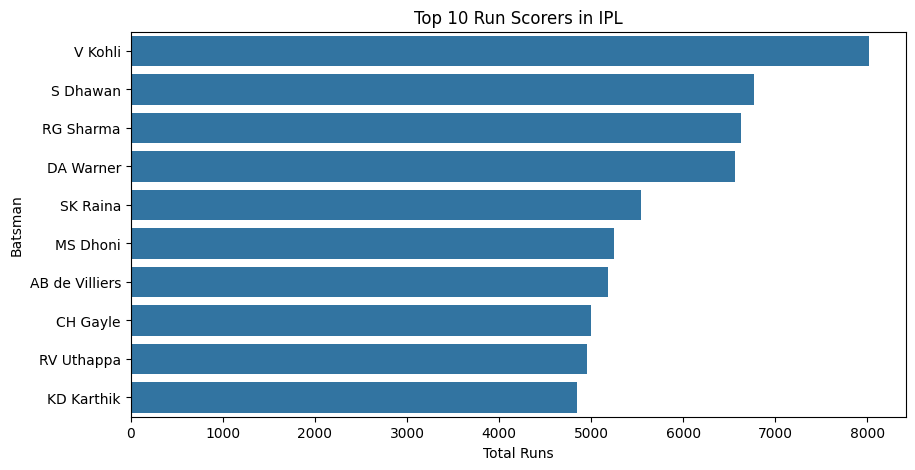

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x="batsman_runs", y="batter", data=top_batsmen)
plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Total Runs")
plt.ylabel("Batsman")
plt.show()

In [13]:
# Strike Rate Analysis
# Strike Rate Analysis

balls_faced = deliveries.groupby("batter")["ball"].count().reset_index(name="balls")
runs = deliveries.groupby("batter")["batsman_runs"].sum().reset_index()

strike_rate = pd.merge(runs, balls_faced, on="batter")

strike_rate["strike_rate"] = (strike_rate["batsman_runs"] / strike_rate["balls"]) * 100

# Minimum balls faced condition
strike_rate = strike_rate[strike_rate["balls"] > 200]

strike_rate.sort_values(by="strike_rate", ascending=False).head(10)

,batter,batsman_runs,balls,strike_rate
433,PD Salt,653,385,169.610390
606,T Stubbs,405,239,169.456067
617,TM Head,772,458,168.558952
39,AD Russell,2488,1515,164.224422
208,H Klaasen,993,613,161.990212
612,TH David,659,417,158.033573
561,SP Narine,1534,984,155.894309
585,Shashank Singh,423,272,155.514706
396,N Pooran,1769,1143,154.768154
323,LS Livingstone,939,609,154.187192


In [14]:
#Team Win Analysis
team_wins = matches["winner"].value_counts().reset_index()
team_wins.columns = ["Team", "Wins"]
team_wins

,Team,Wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bangalore,116
4,Rajasthan Royals,112
5,Sunrisers Hyderabad,88
6,Kings XI Punjab,88
7,Delhi Daredevils,67
8,Delhi Capitals,48
9,Deccan Chargers,29


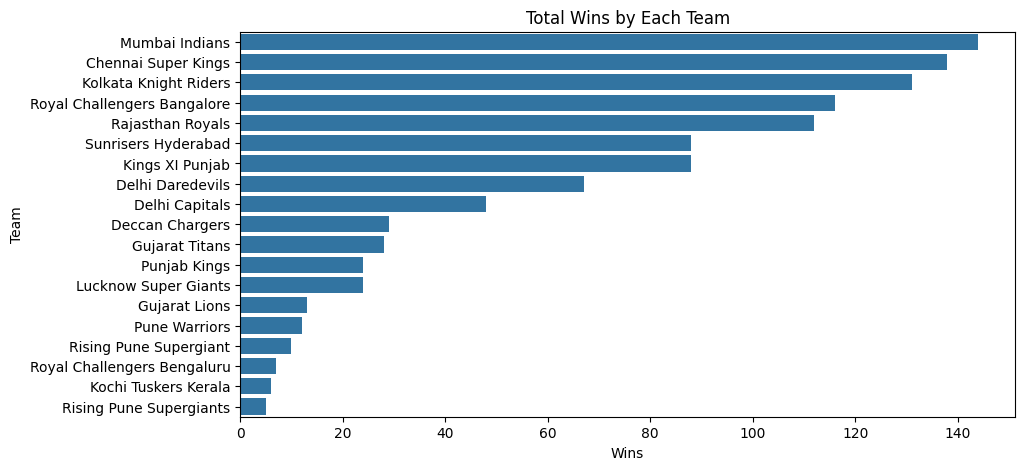

In [15]:
#Visualization
plt.figure(figsize=(10,5))
sns.barplot(x="Wins", y="Team", data=team_wins)
plt.title("Total Wins by Each Team")
plt.show()

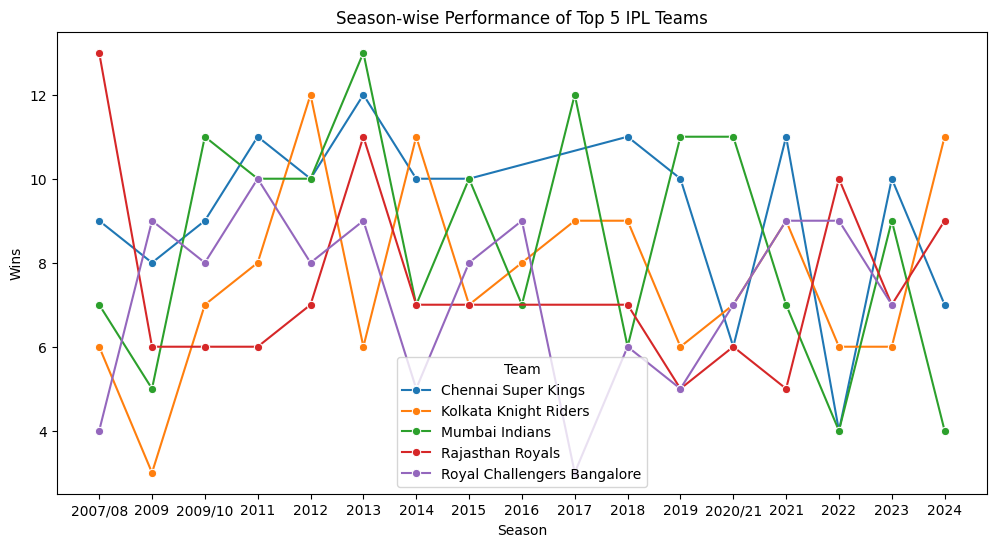

In [17]:
# Season-wise Team Performance (Top 5 Teams Only)

import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
season_wins = (
    matches
    .dropna(subset=["winner"])
    .groupby(["season", "winner"])
    .size()
    .reset_index(name="wins")
)

# Select top 5 teams overall
top_teams = matches["winner"].value_counts().head(5).index

season_wins = season_wins[season_wins["winner"].isin(top_teams)]

# Visualization
plt.figure(figsize=(12,6))
sns.lineplot(
    data=season_wins,
    x="season",
    y="wins",
    hue="winner",
    marker="o"
)

plt.title("Season-wise Performance of Top 5 IPL Teams")
plt.xlabel("Season")
plt.ylabel("Wins")
plt.legend(title="Team")
plt.show()

In [18]:
#Toss vs Match Result Analysis
toss_match = matches[matches["toss_winner"] == matches["winner"]]
percentage = (len(toss_match) / len(matches)) * 100
percentage

50.593607305936075

In [ ]:
#Key Insights
## Key Insights
- Mumbai Indians and CSK are the most successful teams.
- Top batsmen maintain consistency across seasons.
- Toss win does not strongly impact match results.
- Some players perform better in specific seasons.

In [ ]:
#Conclusion
## Conclusion
This IPL data analysis project demonstrates how sports data can be used to
analyze player performance, team consistency, and match trends using Python.